# Notebook — Fonctionnalités

Outils annexes (dataset, sanity checks GT LARD, exports, vidéo).
Les phases generate / export sont dans `notebooks/generation.ipynb`.

> Note : certains helpers ciblent encore l'ancien layout (`runs/`, `footage/`) et doivent être adaptés au nouveau layout (`scenarios/`, `dataset/`, `images/`).

## 1. Setup

**À exécuter en premier.** 

In [ ]:
import sys
from pathlib import Path

def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "main.py").exists():
            return p
    return start

ROOT = _find_root(Path.cwd())

_project = str(ROOT / "sources")
if _project not in sys.path:
    sys.path.insert(0, _project)

from notebook_tools import (
    build_dataset, regroup_images,
    build_lard_box, show_sanity_lard,
    build_xplane_config, build_params_trace,
    build_video,
    find_runs,  # adaptateur retro-compat -> find_scenarios
)
from scenario import SCENARIOS_DIR, DATASET_DIR

print(f"ROOT          = {ROOT}")
print(f"SCENARIOS_DIR = {SCENARIOS_DIR}  (exists={SCENARIOS_DIR.exists()})")
print(f"DATASET_DIR   = {DATASET_DIR}  (exists={DATASET_DIR.exists()})")

## 2. Lister les runs disponibles

Énumère tous les runs valides présents dans `runs/` (toutes générations
confondues), affichés en chemin relatif `<generation>/<run>`.

In [2]:
runs = find_runs(all_runs=True)
for r in runs:
    print(f"  - {r.parent.name}/{r.name}")
print(f"\n{len(runs)} scenario(s) trouve(s).")

  - default__20260715-035404/KSLC-34L__405-smpl__20260715-035404__1
  - default__20260715-035404/ZSSS-00L__405-smpl__20260715-035404__0
  - default__20260715-040901/LFPO-24__405-smpl__20260715-040901__0
  - test__20260715-035620/MMUN-12L__405-smpl__20260715-035620__0
  - test__20260715-035620/WMKK-32L__405-smpl__20260715-035620__1
  - test_full__20260715-040652/EPWA-29__405-smpl__20260715-040652__0

6 scenario(s) trouve(s).


## 3. Création du dataset (arborescence par piste / scénario) à REVOIR / ANCIENNE VERSION mais marche OK




Format aligné sur le CSV LARD natif.

```
dataset/
├── metadata.csv                         # toutes pistes, tous scénarios
└── <ICAO_RWY>/                          # ex: KPDX_10L
    ├── metadata.csv                     # tous scénarios de cette piste
    └── <ICAO_RWY>_<NNN>/                # ex: KPDX_10L_001
        ├── metadata.csv                 # ce scénario uniquement
        └── images/000000.jpg ...
```


In [3]:
build_dataset()

Dataset consolide : C:\Users\Sr-Sh\Desktop\lardon_generation\temp_LARDON_generation\dataset_build
  EPWA-29__405-smpl__20260715-040652__0         <- corrupted_images ( 405 imgs) [ok -> EPWA_29/EPWA_29_001]
  KSLC-34L__405-smpl__20260715-035404__1        <- corrupted_images ( 405 imgs) [ok -> KSLC_34L/KSLC_34L_001]
  WMKK-32L__405-smpl__20260715-035620__1        <- corrupted_images ( 405 imgs) [ok -> WMKK_32L/WMKK_32L_001]
  ZSSS-00L__405-smpl__20260715-035404__0        <- corrupted_images ( 405 imgs) [ok -> ZSSS_00L/ZSSS_00L_001]
Total : 1620 images, 4 piste(s)


{'EPWA-29__405-smpl__20260715-040652__0': ('corrupted_images',
  405,
  'ok -> EPWA_29/EPWA_29_001'),
 'KSLC-34L__405-smpl__20260715-035404__1': ('corrupted_images',
  405,
  'ok -> KSLC_34L/KSLC_34L_001'),
 'WMKK-32L__405-smpl__20260715-035620__1': ('corrupted_images',
  405,
  'ok -> WMKK_32L/WMKK_32L_001'),
 'ZSSS-00L__405-smpl__20260715-035404__0': ('corrupted_images',
  405,
  'ok -> ZSSS_00L/ZSSS_00L_001')}

In [4]:
# regroup_images() — regroupe + renumérote les images du dataset, avec metadata.csv.
#
# mode="piste" (defaut) : un dossier par piste
#     runs/dataset_regroup/<RWY>/img/000000.jpg ...
#     runs/dataset_regroup/<RWY>/metadata.csv      (scenarios de cette piste)
#
# mode="all"            : tout dans un seul dossier
#     runs/dataset_regroup/datasetr/img/000000.jpg ...
#     runs/dataset_regroup/datasetr/metadata.csv   (toutes pistes confondues)
#
# Les deux modes coexistent (chacun ne nettoie que son propre sous-dossier).

#regroup_images(mode="piste")
regroup_images(mode="all")

Regroupement global : C:\Users\Sr-Sh\Desktop\lardon_generation\temp_LARDON_generation\dataset_regroup\datasetr
  EPWA_29          405 imgs
  KSLC_34L         405 imgs
  WMKK_32L         405 imgs
  ZSSS_00L         405 imgs
Total : 1620 images, 4 piste(s)


## 6. Générer `lard_box/` (images avec bbox GT LARD dessinées)

Usage :
- `build_lard_box()`                          : toutes les runs
- `build_lard_box("generation_01/KLAX_25R")`  : chemin composé si conflit

In [2]:
# build_lard_box("generation_01/KLAX_25R")  # un seul run (chemin composé)
build_lard_box()

  KSLC-34L__405-smpl__20260715-035404__1 -> lard_box/ (405/405 avec GT, source: corrupted_images/)
  ZSSS-00L__405-smpl__20260715-035404__0 -> lard_box/ (405/405 avec GT, source: corrupted_images/)
  WMKK-32L__405-smpl__20260715-035620__1 -> lard_box/ (405/405 avec GT, source: corrupted_images/)
  EPWA-29__405-smpl__20260715-040652__0 -> lard_box/ (405/405 avec GT, source: corrupted_images/)


## 7. Sanity check : 3 images avec bbox GT LARD 

Affiche première / milieu / dernière image d'UN run avec les 4 coins GT LARD
(`degraded/` prio sinon `footage/`). Pas de mode "tous les runs" : sans argument,
prend le premier run trouvé.

Usage :
- `show_sanity_lard()`                          : premier run trouvé
- `show_sanity_lard("KLAX_25R")`                : un run cible (si unique)
- `show_sanity_lard("generation_01/KLAX_25R")`  : chemin composé si conflit

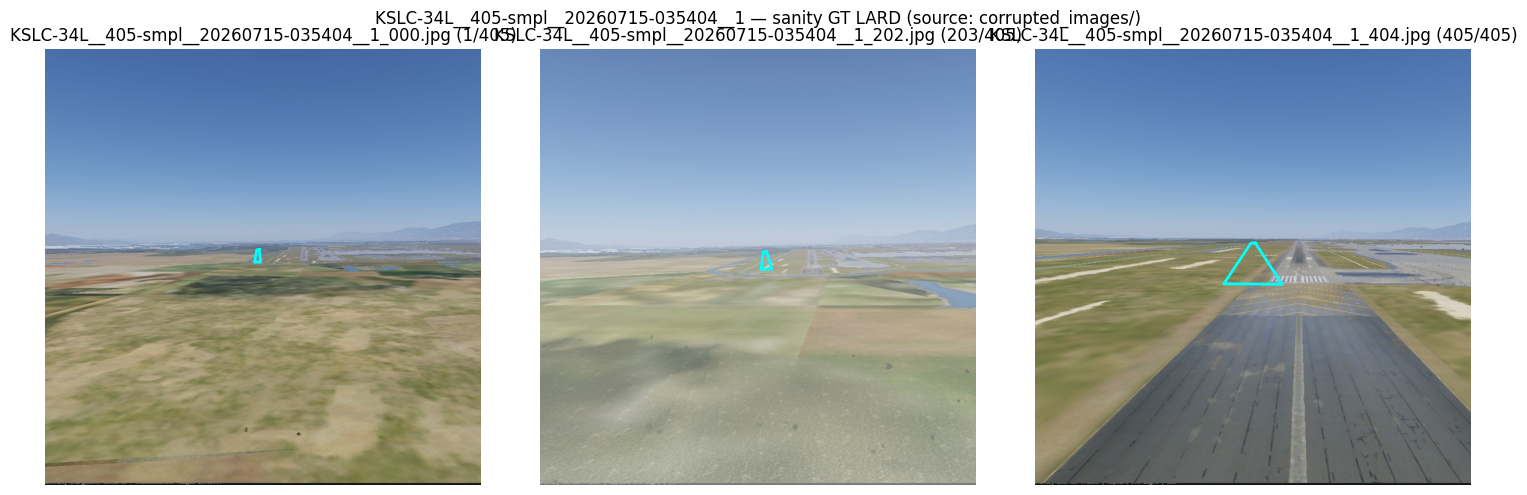

In [3]:
# show_sanity_lard("generation_01/KLAX_25R")  # cible un run spécifique
show_sanity_lard()

## 8. Générer `xplane_config.json`


**Contenu** : `width`/`height` (résolution), `fov_h`/`fov_v` (champ de vision),
`pilot_eye_x/y/z` (position œil pilote sur X-Plane12 dépendant de l'avion choisi), `weather_status` (ok/absent).

Usage :
- `build_xplane_config()`                          : toutes les runs
- `build_xplane_config("generation_01/KLAX_25R")`  : chemin composé si conflit

In [4]:
# build_xplane_config("generation_01/KLAX_25R")  # un seul run (chemin composé)
build_xplane_config()

  KSLC-34L__405-smpl__20260715-035404__1 -> xplane_config.json (1024x1024, weather=ok)
  ZSSS-00L__405-smpl__20260715-035404__0 -> xplane_config.json (1024x1024, weather=ok)
  LFPO-24__405-smpl__20260715-040901__0 -> xplane_config.json (1024x1024, weather=ok)
  MMUN-12L__405-smpl__20260715-035620__0 -> xplane_config.json (1024x1024, weather=ok)
  WMKK-32L__405-smpl__20260715-035620__1 -> xplane_config.json (1024x1024, weather=ok)
  EPWA-29__405-smpl__20260715-040652__0 -> xplane_config.json (1024x1024, weather=ok)


## 9. Générer `params_trace.xml`

**Contenu** : 
 `trajectory` (fps + paramètres de trajectoire), `weather` (paramètres météo), `faults`
(fautes capteur appliquées).

Usage :
- `build_params_trace()`                          : toutes les runs
- `build_params_trace("generation_01/KLAX_25R")`  : chemin composé si conflit

In [5]:
# build_params_trace("generation_01/KLAX_25R")  # un seul run (chemin composé)
build_params_trace()

  KSLC-34L__405-smpl__20260715-035404__1 -> params_trace.xml
  ZSSS-00L__405-smpl__20260715-035404__0 -> params_trace.xml
  LFPO-24__405-smpl__20260715-040901__0 -> params_trace.xml
  MMUN-12L__405-smpl__20260715-035620__0 -> params_trace.xml
  WMKK-32L__405-smpl__20260715-035620__1 -> params_trace.xml
  EPWA-29__405-smpl__20260715-040652__0 -> params_trace.xml


## 10. Generer `.esp` (projet Google Earth Studio)

Reconstruit un projet GES (`<run>.esp`) depuis `poses_cam_export.json`
via LARD `GEODataset.create_scenario`. A importer dans Google Earth Studio
pour le rendu. `fov_vertical=30` = convention historique LARD-GES.

In [6]:
# build_esp("generation_01/KLAX_25R")  # un seul run 
build_esp()


  KSLC-34L__405-smpl__20260715-035404__1 -> KSLC-34L__405-smpl__20260715-035404__1.esp
  ZSSS-00L__405-smpl__20260715-035404__0 -> ZSSS-00L__405-smpl__20260715-035404__0.esp
  LFPO-24__405-smpl__20260715-040901__0 -> LFPO-24__405-smpl__20260715-040901__0.esp
  MMUN-12L__405-smpl__20260715-035620__0 -> MMUN-12L__405-smpl__20260715-035620__0.esp
  WMKK-32L__405-smpl__20260715-035620__1 -> WMKK-32L__405-smpl__20260715-035620__1.esp
  EPWA-29__405-smpl__20260715-040652__0 -> EPWA-29__405-smpl__20260715-040652__0.esp


## 11. Générer une vidéo MP4 d'un run/des runs

Concatène les images du run (`degraded/` en priorité sinon `footage/`) en un MP4 (fps du yaml).

Usage :
- `build_video()`                          : toutes les runs
- `build_video(source="footage")`          : force la source (`footage` ou `degraded`)

In [7]:
# build_video("generation_02/LFPO_25", source="footage")  # run spécifique + source footage
build_video() 

  KSLC-34L__405-smpl__20260715-035404__1 -> KSLC-34L__405-smpl__20260715-035404__1.mp4  (405 frames @ 12fps, corrupted_images/)
  ZSSS-00L__405-smpl__20260715-035404__0 -> ZSSS-00L__405-smpl__20260715-035404__0.mp4  (405 frames @ 12fps, corrupted_images/)
  WMKK-32L__405-smpl__20260715-035620__1 -> WMKK-32L__405-smpl__20260715-035620__1.mp4  (405 frames @ 12fps, corrupted_images/)
  EPWA-29__405-smpl__20260715-040652__0 -> EPWA-29__405-smpl__20260715-040652__0.mp4  (405 frames @ 12fps, corrupted_images/)
